# Solutions · 03 · Linear systems and eigenvalues

Worked solutions to the exercises of [notebook 03](../notebooks/03_linear_systems.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import linalg
L, k, q, T_left, T_right = 0.1, 15.0, 4e5, 20.0, 60.0

## Exercise 1

Change the right boundary of the wall to convection, $-k\,T' = h(T - T_\infty)$, with
   $h$ = 25 W/(m²·K) and $T_\infty$ = 20 °C. Only the last equation of the system changes - which one?

In [2]:
h, T_inf, n = 25.0, 20.0, 50                    # n intervals; unknowns T_1 ... T_n (T_0 fixed)
x = np.linspace(0, L, n + 1); dx = x[1] - x[0]
lower, diag, upper = np.ones(n), -2*np.ones(n), np.ones(n)
rhs = -q*dx**2/k * np.ones(n)
rhs[0] -= T_left
# last node: ghost node T_{n+1} = T_{n-1} - 2 dx h/k (T_n - T_inf) from -k T' = h (T - T_inf)
lower[-1] = 2.0
diag[-1] = -2 - 2*dx*h/k
rhs[-1] = -q*dx**2/k - 2*dx*h/k*T_inf
T = np.r_[T_left, linalg.thomas(lower, diag, upper, rhs)]
C1 = q*L*(1 + h*L/(2*k)) / (k + h*L)                # exact: T = T_left + C1 x - q x^2/(2k)
T_exact = T_left + C1*x - q*x**2/(2*k)
print(f"max error {np.max(np.abs(T - T_exact)):.1e} K; surface T {T[-1]:.1f} °C; maximum {T.max():.1f} °C at x = {x[T.argmax()]*100:.1f} cm")

max error 2.8e-12 K; surface T 134.3 °C; maximum 135.0 °C at x = 9.2 cm


Only the **last row** changes: its coefficients and right-hand side now contain the convection
coefficient. The ghost-node treatment keeps second-order accuracy (here the profile is quadratic, so the
result is exact to rounding). With the weak convection ($h$ = 25 W/(m²·K)) the right face runs far
hotter than the 60 °C it was held at before - convection removes the generated heat much less
effectively than a fixed-temperature wall.

## Exercise 2

Solve the 2D plate with Jacobi iteration and compare the number of sweeps with Gauss-Seidel.

In [3]:
N = 31
def solve_plate(method, tol=1e-7):
    T = np.zeros((N, N)); T[0, :] = 100.0
    for sweep in range(1, 20000):
        old = T.copy()
        if method == "jacobi":             # every node from the OLD values (vectorised)
            T[1:-1, 1:-1] = 0.25*(old[2:, 1:-1] + old[:-2, 1:-1] + old[1:-1, 2:] + old[1:-1, :-2])
        else:                              # Gauss-Seidel: newest values as soon as available
            for i in range(1, N-1):
                for j in range(1, N-1):
                    T[i, j] = 0.25*(T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1])
        if np.max(np.abs(T - old)) < tol:
            return sweep, T[N//2, N//2]
for m in ("jacobi", "gauss-seidel"):
    sweeps, centre = solve_plate(m)
    print(f"{m:<13}: {sweeps:5d} sweeps, centre {centre:.4f} °C")

jacobi       :  2662 sweeps, centre 25.0000 °C


gauss-seidel :  1388 sweeps, centre 25.0000 °C


Jacobi needs about **twice** as many sweeps as Gauss-Seidel - the classical result for this problem,
because Gauss-Seidel uses each updated value immediately. Jacobi has one practical advantage: every
node can be updated independently, so it vectorises (as here) and parallelises perfectly.

## Exercise 3

For the mass-spring chain, how do the frequencies change if the middle mass is doubled?

In [4]:
import scipy.linalg as sla
m_, ks, nm = 2.0, 1.5e4, 5
K = ks*(2*np.eye(nm) - np.eye(nm, k=1) - np.eye(nm, k=-1))
for label, masses in (("equal masses", [m_]*5), ("middle mass doubled", [m_, m_, 2*m_, m_, m_])):
    lam, modes = sla.eigh(K, np.diag(masses))       # K v = omega^2 M v
    print(f"{label:<20}: {np.round(np.sqrt(lam)/(2*np.pi), 2)} Hz")

equal masses        : [ 7.13 13.78 19.49 23.87 26.63] Hz
middle mass doubled : [ 6.13 13.78 17.19 23.87 24.84] Hz


The heavier middle mass lowers the 1st, 3rd and 5th frequencies but leaves the **2nd and 4th unchanged**.
Those modes are antisymmetric: the middle mass sits at a node and does not move, so its mass cannot
matter. A general rule: added mass lowers a natural frequency only in proportion to how much the mass
moves in that mode - which is why engineers look at mode shapes, not just frequencies.

## Exercise 4

**Implement it yourself:** add successive over-relaxation (SOR) to the 2D plate loop: compute the Gauss-Seidel value $T_{GS}$, then set $T \leftarrow T + \omega(T_{GS} - T)$. Find the $\omega$ between 1.0 and 1.95 that needs the fewest sweeps.

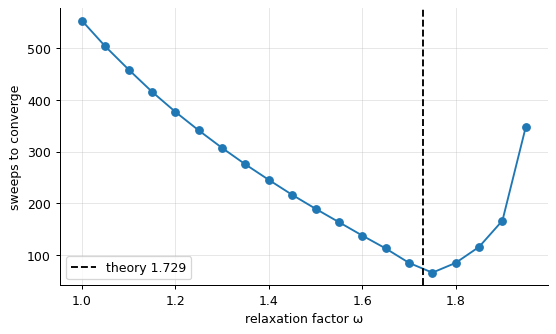

Gauss-Seidel (ω = 1): 554 sweeps; best ω = 1.75: 65 sweeps


In [5]:
Ns = 21
def sor_sweeps(omega, tol=1e-6):
    T = np.zeros((Ns, Ns)); T[0, :] = 100.0
    for sweep in range(1, 5000):
        change = 0.0
        for i in range(1, Ns-1):
            for j in range(1, Ns-1):
                gs = 0.25*(T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1])
                new = T[i, j] + omega*(gs - T[i, j])
                change = max(change, abs(new - T[i, j])); T[i, j] = new
        if change < tol:
            return sweep
omegas = np.arange(1.0, 1.96, 0.05)
counts = [sor_sweeps(w) for w in omegas]
best = omegas[int(np.argmin(counts))]
theory = 2 / (1 + np.sin(np.pi / (Ns - 1)))
plt.plot(omegas, counts, "o-"); plt.axvline(theory, color="k", ls="--", label=f"theory {theory:.3f}")
plt.xlabel("relaxation factor ω"); plt.ylabel("sweeps to converge"); plt.legend(); plt.show()
print(f"Gauss-Seidel (ω = 1): {counts[0]} sweeps; best ω = {best:.2f}: {min(counts)} sweeps")

Over-relaxation cuts the number of sweeps several-fold. The best factor agrees with the theoretical
optimum $\omega = 2/(1 + \sin(\pi/(N-1)))$ for this model problem. Too large an $\omega$ makes the iteration
oscillate, and at $\omega \ge 2$ it diverges.